In [1]:
import os

# This lists every directory in your input folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/tanziarahman
/kaggle/input/datasets/tanziarahman/plant-doc
/kaggle/input/datasets/tanziarahman/plant-doc/processed
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val/Early Blight
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val/Bacterial Spot
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val/Septoria Leaf Spot
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val/Healthy
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val/Late Blight
/kaggle/input/datasets/tanziarahman/plant-doc/processed/val/Yellow Leaf Curl Virus
/kaggle/input/datasets/tanziarahman/plant-doc/processed/test
/kaggle/input/datasets/tanziarahman/plant-doc/processed/test/Early Blight
/kaggle/input/datasets/tanziarahman/plant-doc/processed/test/Bacterial Spot
/kaggle/input/datasets/tanziarahman/plant-doc/processed/test/Septoria Leaf Spot
/kaggle/input/datasets/t

In [2]:
# imports
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import warnings

# --- Kaggle Specific Adjustment ---
# This ignores minor warnings that often pop up in Kaggle's environment
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# cudnn.benchmark = True is great for Kaggle GPUs (T4 or P100) 
# as it speeds up training for fixed image sizes
torch.backends.cudnn.benchmark = True

# Detect Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

if DEVICE.type == 'cuda':
    # Kaggle often gives you two T4 GPUs, this checks the one you are using
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print("WARNING: GPU is not enabled. Go to Settings > Accelerator to turn it on!")

Device: cuda
GPU: Tesla T4


In [4]:
# --- Define your Kaggle Path ---
# Renamed to DATA_ROOT as requested
DATA_ROOT = '/kaggle/input/datasets/tanziarahman/plant-doc/processed'

# Verify the path and check contents
if os.path.exists(DATA_ROOT):
    items = os.listdir(DATA_ROOT)
    print(f"✅ Successfully connected to: {DATA_ROOT}")
    print(f"📊 Items found: {len(items)}")
    
    # Check if we have subfolders (classes) or just files
    subfolders = [f for f in items if os.path.isdir(os.path.join(DATA_ROOT, f))]
    if len(subfolders) > 0:
        print(f"📂 Detected {len(subfolders)} class folders.")
        print(f"Sample classes: {subfolders[:5]}")
    else:
        print("📝 No subfolders detected. Files are likely directly in the processed folder.")
else:
    print(f"❌ ERROR: The path {DATA_ROOT} does not exist.")
    print("Double check your dataset name in the 'Input' section on the right sidebar.")

# --- Device Setup ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nRunning on: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')

✅ Successfully connected to: /kaggle/input/datasets/tanziarahman/plant-doc/processed
📊 Items found: 3
📂 Detected 3 class folders.
Sample classes: ['val', 'test', 'train']

Running on: cuda
GPU Name: Tesla T4


In [5]:
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT_P    = 0.3
NUM_WORKERS  = 2

NUM_CLASSES = len(os.listdir(os.path.join(DATA_ROOT, 'train')))
print(f'Classes found: {NUM_CLASSES}')

Classes found: 6


In [7]:
#Transforms
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [8]:
# Datasets & Loaders
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'val'),   transform=val_tf)

class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 4620 | Val: 58
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [9]:
# MobileNetV2 from Scratch
import torch.nn as nn
import torch.nn.functional as F

def conv_3x3_bn(in_ch, out_ch, stride):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU6(inplace=True) # MobileNetV2 uses ReLU6
    )

def conv_1x1_bn(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 1, 1, 0, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU6(inplace=True)
    )

class InvertedResidual(nn.Module):
    def __init__(self, in_ch, out_ch, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        hidden_dim = int(round(in_ch * expand_ratio))
        self.use_res_connect = self.stride == 1 and in_ch == out_ch

        layers = []
        if expand_ratio != 1:
            # pw (pointwise expansion)
            layers.append(conv_1x1_bn(in_ch, hidden_dim))

        layers.extend([
            # dw (depthwise)
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            # pw-linear (projection)
            nn.Conv2d(hidden_dim, out_ch, 1, 1, 0, bias=False),
            nn.BatchNorm2d(out_ch),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_P):
        super().__init__()
        # t, c, n, s (expansion factor, channels, number of blocks, stride)
        self.configs = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        # Stem
        input_channel = 32
        self.stem = conv_3x3_bn(3, input_channel, 2)

        # Build blocks
        layers = []
        for t, c, n, s in self.configs:
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedResidual(input_channel, c, stride, expand_ratio=t))
                input_channel = c
        self.features = nn.Sequential(*layers)

        # Head
        self.conv_last = conv_1x1_bn(input_channel, 1280)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes)
        )

        # Weight Initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.conv_last(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Create model and move to GPU
model = MobileNetV2().to(DEVICE)

# Calculate parameters (Will be ~2.2M, compared to ResNet18's ~11M)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Total parameters: 2.23M


In [10]:
# Loss / Optimizer / Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR_MAX / 25, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_dl),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

scaler = GradScaler()

In [11]:
from tqdm.auto import tqdm
import copy, time

# --- Kaggle Update: Use the working directory for saving ---
SAVE_PATH = '/kaggle/working/mobilenet_latest.pth'

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    desc = 'Train' if train else 'Val'
    # tqdm.auto works better in Kaggle's web interface
    pbar = tqdm(loader, desc=desc, leave=False, ncols=80)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}',
                             acc=f'{correct/total:.2%}')

    return total_loss / total, correct / total

# --- Main Training Loop ---
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        tag = ' ★'
        # Also save a separate 'best' file for easy downloading later
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
    else:
        tag = ''

    # Save checkpoint to Kaggle Working Directory
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, SAVE_PATH)

    print(f'Epoch {epoch:>3} | TrLoss={tr_loss:.4f} TrAcc={tr_acc:.2%} | VaLoss={va_loss:.4f} VaAcc={va_acc:.2%} | {elapsed:.0f}s{tag}')

# Load the star (best) weights before moving to evaluation
model.load_state_dict(best_wts)
print(f'\nFinished! Best val accuracy: {best_acc:.4%}')

Train:   0%|                                             | 0/73 [00:00<?, ?it/s]

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

Epoch   1 | TrLoss=1.7860 TrAcc=19.98% | VaLoss=1.8700 VaAcc=18.97% | 86s ★


Train:   0%|                                             | 0/73 [00:00<?, ?it/s]

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

...

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

Epoch  39 | TrLoss=1.1477 TrAcc=62.88% | VaLoss=1.3854 VaAcc=48.28% | 27s


Train:   0%|                                             | 0/73 [00:00<?, ?it/s]

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

Epoch  40 | TrLoss=1.1673 TrAcc=61.19% | VaLoss=1.3933 VaAcc=46.55% | 26s

Finished! Best val accuracy: 53.4483%


In [12]:
from tqdm.auto import tqdm
import copy, time

# --- Configuration & Path Setup ---
# Ensure SAVE_PATH matches your main loop
SAVE_PATH = '/kaggle/working/mobilenet_latest.pth'
BEST_MODEL_PATH = '/kaggle/working/best_model.pth'

# Load the checkpoint
checkpoint = torch.load(SAVE_PATH)

# Restore states
model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])
best_acc    = checkpoint['best_val_acc']
history     = checkpoint['history']
start_epoch = checkpoint['epoch'] + 1

print(f'Resuming from epoch {start_epoch}, best acc so far: {best_acc:.4%}')

# --- Resume Settings ---
EXTRA_EPOCHS = 20
total_epochs = start_epoch + EXTRA_EPOCHS - 1

# Re-initialize scheduler to match the batch-level stepping in run_epoch
# Note: T_max here should reflect the remaining iterations if you want perfect 
# Cosine Annealing, but often a fresh scheduler for fine-tuning works well.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EXTRA_EPOCHS * len(train_dl), eta_min=1e-6)

best_wts = copy.deepcopy(model.state_dict())

# --- Resume Loop ---
for epoch in range(start_epoch, total_epochs + 1):
    t0 = time.time()

    # Match main loop: Pass scheduler to run_epoch for batch-level stepping
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, None,      scaler, train=False)

    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        tag = ' ★'
        # Save separate best model file
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        tag = ''

    # Save checkpoint (latest)
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, SAVE_PATH)

    print(f'Epoch {epoch:>3} | TrLoss={tr_loss:.4f} TrAcc={tr_acc:.2%} | VaLoss={va_loss:.4f} VaAcc={va_acc:.2%} | {elapsed:.0f}s{tag}')

# --- Final Save for Best Model ---
model.load_state_dict(best_wts)
torch.save({
    'model_state': model.state_dict(),
    'classes': getattr(train_ds, 'classes', None), # Safeguard if classes not in dataset
    'best_val_acc': best_acc
}, '/kaggle/working/mobilenetv2_final_best.pth')

print(f'\nFinished! Best val accuracy: {best_acc:.4%}')

Resuming from epoch 41, best acc so far: 53.4483%


Train:   0%|                                             | 0/73 [00:00<?, ?it/s]

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

Epoch  41 | TrLoss=1.1674 TrAcc=62.06% | VaLoss=1.3780 VaAcc=50.00% | 26s


Train:   0%|                                             | 0/73 [00:00<?, ?it/s]

...

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

Epoch  59 | TrLoss=1.1633 TrAcc=62.49% | VaLoss=1.3907 VaAcc=46.55% | 30s


Train:   0%|                                             | 0/73 [00:00<?, ?it/s]

Val:   0%|                                                | 0/1 [00:00<?, ?it/s]

Epoch  60 | TrLoss=1.1655 TrAcc=60.91% | VaLoss=1.3902 VaAcc=44.83% | 31s

Finished! Best val accuracy: 53.4483%


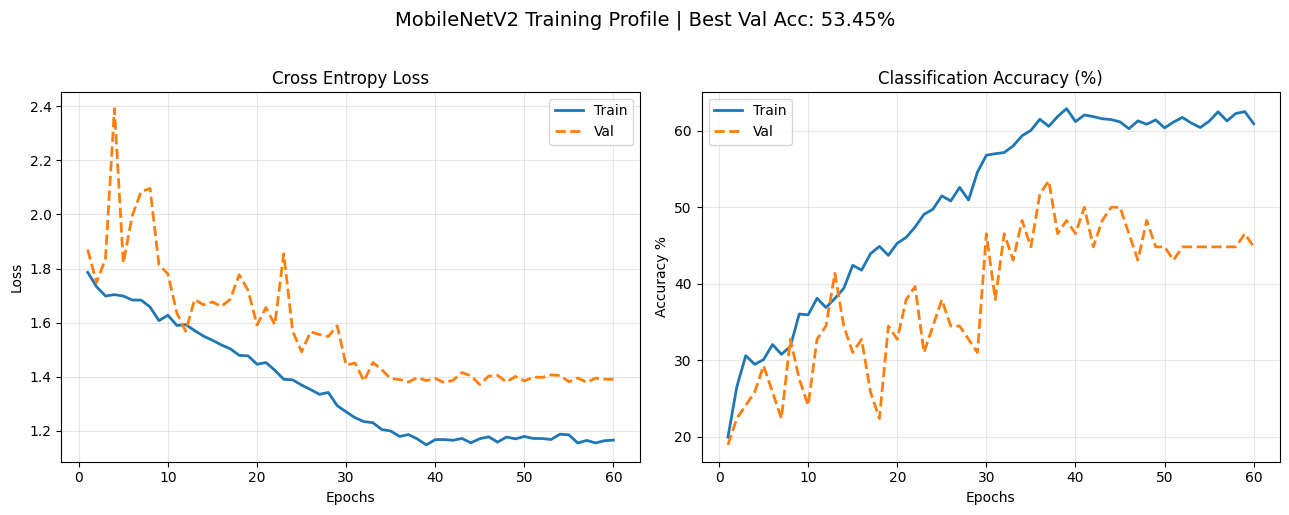

Curves saved to: /kaggle/working/mobilenetv2_training_curves.png


In [13]:
import matplotlib.pyplot as plt

# --- Plotting Configuration ---
# Use the same figure size and style as your training logs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history['train_loss']) + 1)

# Plot Loss
axes[0].plot(ep, history['train_loss'], label='Train', color='#1f77b4', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#ff7f0e', linestyle='--', linewidth=2)
axes[0].set_title('Cross Entropy Loss', fontsize=12)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
# Multiplied by 100 to show as percentage (consistent with your print statements)
axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='#1f77b4', linewidth=2)
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='#ff7f0e', linestyle='--', linewidth=2)
axes[1].set_title('Classification Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Main Title - Reflecting the MobileNetV2 architecture and best result
plt.suptitle(f'MobileNetV2 Training Profile | Best Val Acc: {best_acc:.2%}', fontsize=14, y=1.02)
plt.tight_layout()

# --- Kaggle Update: Save to the working directory ---
SAVE_PLOT_PATH = '/kaggle/working/mobilenetv2_training_curves.png'
plt.savefig(SAVE_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"Curves saved to: {SAVE_PLOT_PATH}")

In [15]:
import os

# --- Configuration & Path Setup ---
# Match the 'Final Save' name from your training/resume block
BEST_PATH = '/kaggle/working/mobilenetv2_final_best.pth'

# Quick check to see if the file exists before loading
if not os.path.exists(BEST_PATH):
    print(f"❌ Error: File not found at {BEST_PATH}")
    print("Double-check your previous code block to see what name you saved it as.")
else:
    # Load the checkpoint
    checkpoint = torch.load(BEST_PATH, map_location=DEVICE)

    # Re-initialize the MobileNetV2 architecture
    model = MobileNetV2(num_classes=NUM_CLASSES).to(DEVICE)

    # Load the state dictionary
    model.load_state_dict(checkpoint['model_state'])

    # Set to evaluation mode
    model.eval()

    print(f"✅ MobileNetV2 loaded successfully!")
    print(f"⭐ Best Validation Accuracy: {checkpoint['best_val_acc']:.2%}")

✅ MobileNetV2 loaded successfully!
⭐ Best Validation Accuracy: 53.45%


In [16]:
# Final Evaluation for MobileNetV2 on PlantDoc
test_path = os.path.join(DATA_ROOT, 'test')
eval_path = test_path if os.path.exists(test_path) else os.path.join(DATA_ROOT, 'val')

# Use the validation transforms (val_tf) for consistency
eval_ds = datasets.ImageFolder(eval_path, transform=val_tf)
eval_dl = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=True)

# Ensure model is in eval mode
model.eval()
all_preds, all_labels = [], []

print(f"Evaluating MobileNetV2 on {os.path.basename(eval_path)} set...")

with torch.no_grad():
    for imgs, labels in eval_dl:
        with autocast():
            # Pass images to GPU
            out = model(imgs.to(DEVICE))

        # Store predictions and labels for later analysis
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(labels)

# Concatenate all batches
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Calculate global accuracy
overall = (all_preds == all_labels).float().mean().item()
print(f'\nOverall accuracy on {os.path.basename(eval_path)}: {overall:.4%}\n')

# Per-class accuracy breakdown
print(f"{'Class Name':40s} | {'Accuracy':8s} | {'Count'}")
print("-" * 60)
for i, cls in enumerate(eval_ds.classes):
    mask = (all_labels == i)
    if mask.sum().item() > 0:
        acc = (all_preds[mask] == all_labels[mask]).float().mean().item()
        print(f'  {cls:40s}  {acc:6.2%}  (n={mask.sum().item()})')
    else:
        print(f'  {cls:40s}  No samples found in {os.path.basename(eval_path)} set.')

Evaluating MobileNetV2 on test set...

Overall accuracy on test: 31.0345%

Class Name                               | Accuracy | Count
------------------------------------------------------------
  Bacterial Spot                             0.00%  (n=10)
  Early Blight                              55.56%  (n=9)
  Healthy                                   33.33%  (n=6)
  Late Blight                               27.27%  (n=11)
  Septoria Leaf Spot                        26.67%  (n=15)
  Yellow Leaf Curl Virus                    57.14%  (n=7)


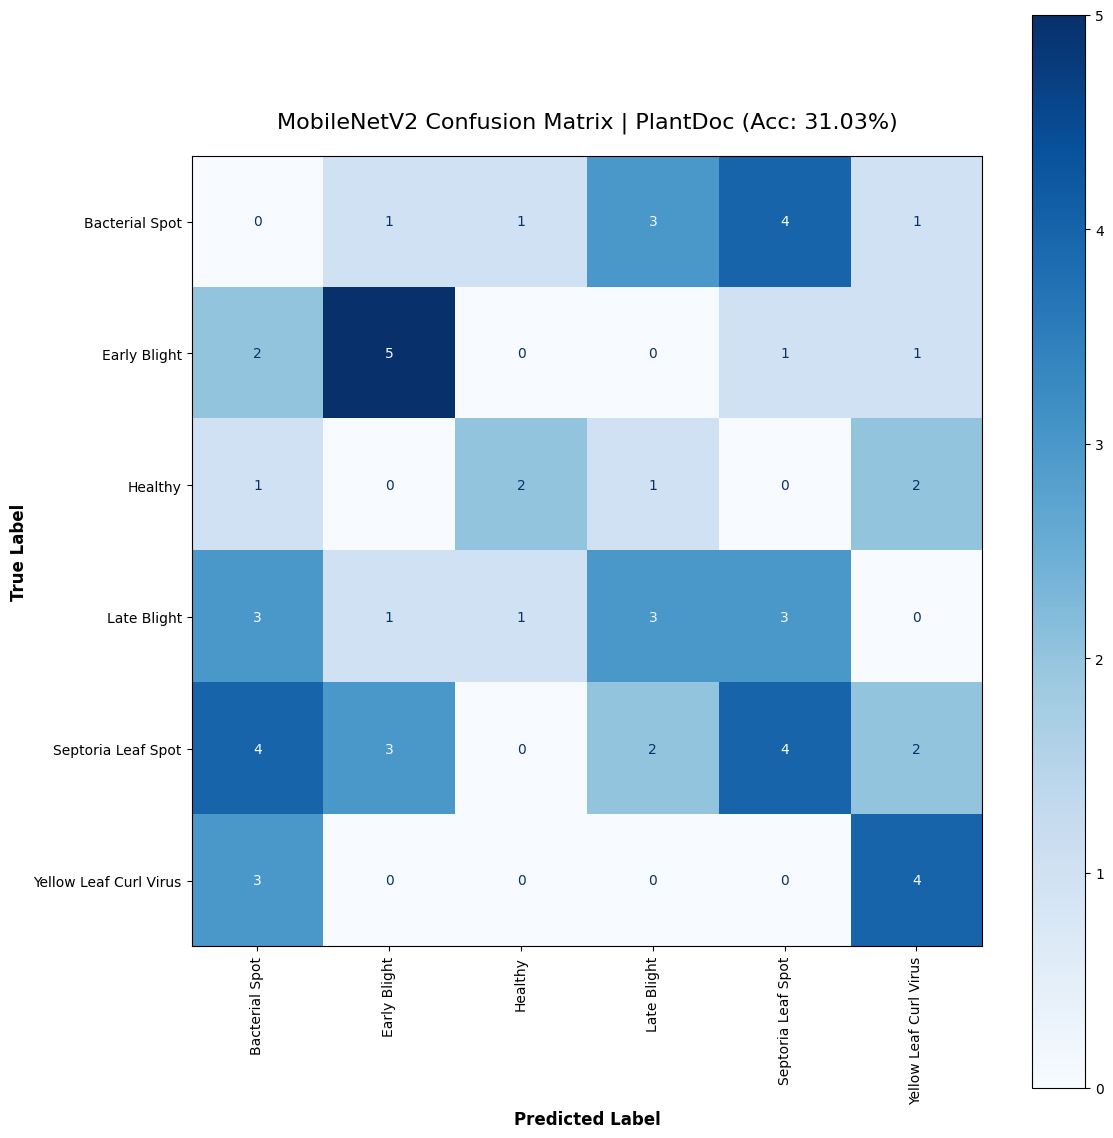

Confusion Matrix saved to: /kaggle/working/mobilenetv2_confusion_matrix.png


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Compute Matrix ---
# Ensure all_labels and all_preds are on CPU for sklearn
y_true = all_labels.numpy() if torch.is_tensor(all_labels) else all_labels
y_pred = all_preds.numpy() if torch.is_tensor(all_preds) else all_preds

cm = confusion_matrix(y_true, y_pred)

# --- 2. Dynamic Sizing ---
# PlantDoc is dense; scaling the figure prevents overlapping text
fig_size = max(12, NUM_CLASSES // 1.5)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

# --- 3. Plotting ---
# Using eval_ds.classes for labeling the axes
cmd = ConfusionMatrixDisplay(cm, display_labels=eval_ds.classes)
cmd.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap='Blues', values_format='d')

# Customizing the look for consistency
plt.title(f'MobileNetV2 Confusion Matrix | PlantDoc (Acc: {overall:.2%})', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()

# --- 4. Kaggle Save Path ---
CM_SAVE_PATH = '/kaggle/working/mobilenetv2_confusion_matrix.png'
plt.savefig(CM_SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion Matrix saved to: {CM_SAVE_PATH}")

In [18]:
from sklearn.metrics import classification_report
import os

# --- 1. Data Preparation ---
# Ensure tensors are on CPU and converted to numpy for sklearn
y_true = all_labels.cpu().numpy() if torch.is_tensor(all_labels) else all_labels
y_pred = all_preds.cpu().numpy() if torch.is_tensor(all_preds) else all_preds

# --- 2. Generate Report ---
# target_names uses eval_ds.classes for PlantDoc category labels
report = classification_report(
    y_true, 
    y_pred, 
    target_names=eval_ds.classes,
    digits=4  # Increased precision to match your '.4f' training logs
)

# --- 3. Display Results ---
header = f"{'='*30} MobileNetV2 - PlantDoc {'='*30}"
footer = f"{'='*len(header)}"

print(header)
print(report)
print(f"Overall Accuracy: {overall:.2%}") # 'overall' from your eval step
print(footer)

# --- 4. Kaggle Save Path ---
REPORT_SAVE_PATH = '/kaggle/working/mobilenetv2_classification_report.txt'

with open(REPORT_SAVE_PATH, 'w') as f:
    f.write(header + '\n')
    f.write(report)
    f.write(f"\nOverall Accuracy: {overall:.2%}\n")
    f.write(footer)

print(f"📄 Full report saved to: {REPORT_SAVE_PATH}")

============================== MobileNetV2 - PlantDoc ==============================
                        precision    recall  f1-score   support

        Bacterial Spot     0.0000    0.0000    0.0000        10
          Early Blight     0.5000    0.5556    0.5263         9
               Healthy     0.5000    0.3333    0.4000         6
           Late Blight     0.3333    0.2727    0.3000        11
    Septoria Leaf Spot     0.3333    0.2667    0.2963        15
Yellow Leaf Curl Virus     0.4000    0.5714    0.4706         7

              accuracy                         0.3103        58
             macro avg     0.3444    0.3333    0.3322        58
          weighted avg     0.3270    0.3103    0.3134        58

Overall Accuracy: 31.03%
📄 Full report saved to: /kaggle/working/mobilenetv2_classification_report.txt
